In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm import tqdm
from Bio.Seq import Seq
tqdm.pandas()

## Preprocessing raw data

In [ ]:
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/dasm")
wyatt_df = pd.read_csv(data_dir / "wyatt-10x-1p5m_fs-all-NoWinCheck-UnmutInv-GTR-paired-merged_pcp_2024-11-21_DXSMVALID_no-naive_ConsCys_HL.csv", index_col=0)
vanwinkle_igh_df = pd.read_csv(data_dir / "v3convert_vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_train_no-naive_DXSMVALID_ConsCys.csv", index_col=0)
vanwinkle_igk_df = pd.read_csv(data_dir / "v3convert_vanwinkle-170-igk_pcp_2025-02-22_MASKED_NI_train_DXSMVALID_ConsCys_no-naive_downsample_500k_CONCAT_vanwinkle-170-igl_pcp_2025-02-25_MASKED_NI_train_DXSMVALID_ConsCys_no-naive_downsample_500k.csv", index_col=0)
tang_df = pd.read_csv(data_dir / "tang-deepshm-prod-NoWinCheck_igh_pcp_2024-10-29_MASKED_NI_ConsCys_no-naive_DXSMVALID.csv", index_col=0)

(209599, 30)

In [75]:
def get_edge_ids(df):
    df['family'] = df['sample_id'] + '_' + df['family'].astype(str)
    df['edge_id'] = df['family'] + ';' + df['parent_name'] + ';' + df['child_name']
    return df

def remove_aligned_gaps(seqA: str, seqB: str):
    """
    Remove gaps from seqA and seqB that are aligned to each other.
    """
    assert len(seqA) == len(seqB)
    new_seqA = []
    new_seqB = []
    for a, b in zip(seqA, seqB):
        if a != '-' or b != '-':
            new_seqA.append(a)
            new_seqB.append(b)
    assert len(new_seqA) == len(new_seqB), "Sequences are not of the same length after gap removal."
    return ''.join(new_seqA), ''.join(new_seqB)

def remove_all_gaps(seq: str) -> str:
    """
    Remove all gaps from a sequence.
    """
    return seq.replace('-', '')

def count_muts(seqA: str, seqB: str) -> int:
    """
    Count the number of mutations between two sequences.
    """
    assert len(seqA) == len(seqB)
    return sum(a != b for a, b in zip(seqA, seqB))

def handle_gaps_and_count_muts(df: pd.DataFrame) -> pd.DataFrame:
    if 'parent_heavy' not in df.columns and 'parent_light' not in df.columns:
        return df

    if 'parent_heavy' in df.columns:
        aligned_heavy = df.progress_apply(lambda x: remove_aligned_gaps(x.parent_heavy, x.child_heavy), axis=1)
        df['parent_heavy'] = aligned_heavy.progress_apply(lambda x: x[0])
        df['child_heavy'] = aligned_heavy.progress_apply(lambda x: x[1])
        df['parent_heavy_aa'] = df['parent_heavy'].progress_apply(lambda x: str(Seq(remove_all_gaps(x)).translate()))
        df['child_heavy_aa'] = df['child_heavy'].progress_apply(lambda x: str(Seq(remove_all_gaps(x)).translate()))

        df['n_mut_heavy'] = df.progress_apply(lambda x: (np.array(list(x.parent_heavy)) != np.array(list(x.child_heavy))).sum(), axis=1)
        df['n_ins_heavy'] = df.progress_apply(lambda x: (np.array(list(x.parent_heavy)) == '-').sum(), axis=1)
        df['n_del_heavy'] = df.progress_apply(lambda x: (np.array(list(x.child_heavy)) == '-').sum(), axis=1)
        df['n_sub_heavy'] = df['n_mut_heavy'] - df['n_ins_heavy'] - df['n_del_heavy']
        assert (df['n_sub_heavy'] >= 0).all(), "Negative substitutions in heavy chain."

    if 'parent_light' in df.columns:
        aligned_light = df.progress_apply(lambda x: remove_aligned_gaps(x.parent_light, x.child_light), axis=1)
        df['parent_light'] = aligned_light.progress_apply(lambda x: x[0])
        df['child_light'] = aligned_light.progress_apply(lambda x: x[1])
        df['parent_light_aa'] = df['parent_light'].progress_apply(lambda x: str(Seq(remove_all_gaps(x)).translate()))
        df['child_light_aa'] = df['child_light'].progress_apply(lambda x: str(Seq(remove_all_gaps(x)).translate()))
    
        df['n_mut_light'] = df.progress_apply(lambda x: (np.array(list(x.parent_light)) != np.array(list(x.child_light))).sum(), axis=1)
        df['n_ins_light'] = df.progress_apply(lambda x: (np.array(list(x.parent_light)) == '-').sum(), axis=1)
        df['n_del_light'] = df.progress_apply(lambda x: (np.array(list(x.child_light)) == '-').sum(), axis=1)
        df['n_sub_light'] = df['n_mut_light'] - df['n_ins_light'] - df['n_del_light']
        assert (df['n_sub_light'] >= 0).all(), "Negative substitutions in light chain."

    if 'n_mut_heavy' in df.columns and 'n_mut_light' in df.columns:
        df['n_mut'] = df['n_mut_heavy'] + df['n_mut_light']
        df['n_sub'] = df['n_sub_heavy'] + df['n_sub_light']
        df['n_del'] = df['n_del_heavy'] + df['n_del_light']
        df['n_ins'] = df['n_ins_heavy'] + df['n_ins_light']
        df['has_indels'] = df['n_ins'] + df['n_del'] > 0
    elif 'n_mut_heavy' in df.columns:
        df['n_mut'] = df['n_mut_heavy']
        df['n_sub'] = df['n_sub_heavy']
        df['n_del'] = df['n_del_heavy']
        df['n_ins'] = df['n_ins_heavy']
        df['has_indels'] = df['n_ins'] + df['n_del'] > 0
    elif 'n_mut_light' in df.columns:
        df['n_mut'] = df['n_mut_light']
        df['n_sub'] = df['n_sub_light']
        df['n_del'] = df['n_del_light']
        df['n_ins'] = df['n_ins_light']
        df['has_indels'] = df['n_ins'] + df['n_del'] > 0

    return df

In [60]:
# try pairing the heavy and light chains in the vanwinkle dataset
vanwinkle_igl_df = vanwinkle_igk_df[vanwinkle_igk_df['sample_id'].str.endswith('-igl')]
vanwinkle_igk_df = vanwinkle_igk_df[vanwinkle_igk_df['sample_id'].str.endswith('-igk')]
assert all(vanwinkle_igh_df['sample_id'].str.endswith('-igh'))
print(f"VanWinkle IGH: {len(vanwinkle_igh_df)}, IGK: {len(vanwinkle_igk_df)}, IGL: {len(vanwinkle_igl_df)}")

# Extract base sample IDs (remove chain suffix)
vanwinkle_igh_df['sample_id'] = vanwinkle_igh_df['sample_id'].str.replace('-igh', '')
vanwinkle_igl_df['sample_id'] = vanwinkle_igl_df['sample_id'].str.replace('-igl', '')
vanwinkle_igk_df['sample_id'] = vanwinkle_igk_df['sample_id'].str.replace('-igk', '')

# Create edge ids for each dataframe
vanwinkle_igh_df = get_edge_ids(vanwinkle_igh_df)
vanwinkle_igk_df = get_edge_ids(vanwinkle_igk_df)
vanwinkle_igl_df = get_edge_ids(vanwinkle_igl_df)

# Check for overlapping edges between IGH and light chains
overlap_igk = (vanwinkle_igk_df['edge_id'].isin(vanwinkle_igh_df['edge_id']) & ~vanwinkle_igk_df['edge_id'].isin(vanwinkle_igl_df['edge_id']))
overlap_igl = (vanwinkle_igl_df['edge_id'].isin(vanwinkle_igh_df['edge_id']) & ~vanwinkle_igl_df['edge_id'].isin(vanwinkle_igk_df['edge_id']))

vanwinkle_igk_df = vanwinkle_igk_df[overlap_igk]
vanwinkle_igl_df = vanwinkle_igl_df[overlap_igl]

overlap_igh = (vanwinkle_igh_df['edge_id'].isin(vanwinkle_igk_df['edge_id']) | vanwinkle_igh_df['edge_id'].isin(vanwinkle_igl_df['edge_id']))
vanwinkle_igh_df = vanwinkle_igh_df[overlap_igh]

# Check final counts
print(f"After pairing - VanWinkle IGH: {len(vanwinkle_igh_df)}, IGK: {len(vanwinkle_igk_df)}, IGL: {len(vanwinkle_igl_df)}")

VanWinkle IGH: 124985, IGK: 500000, IGL: 500000
After pairing - VanWinkle IGH: 290, IGK: 88, IGL: 202


In [63]:
merge_cols = ['sample_id', 'family', 'parent_name', 'child_name', 'edge_id']
heavy_kappa = pd.merge(vanwinkle_igh_df, vanwinkle_igk_df, on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
heavy_lambd = pd.merge(vanwinkle_igh_df, vanwinkle_igl_df, on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
full_df = pd.concat([heavy_kappa, heavy_lambd], axis=0)

In [66]:
from scipy.stats import spearmanr
spearmanr(full_df.branch_length_heavy, full_df.branch_length_light)

SignificanceResult(statistic=0.0736671189251092, pvalue=0.21101188438945484)

In [ ]:
df_branch_lengths_merged = pd.DataFrame({
    "Branch Length": np.concatenate([
        wyatt_df.branch_length.values,
        vanwinkle_igh_df.branch_length.values,
        vanwinkle_igk_df.branch_length.values,
        tang_df.branch_length.values,
    ]),
    "Dataset": ["Wyatt et al. 10x Genomics"] * len(wyatt_df) +
                ["VanWinkle et al. IGH"] * len(vanwinkle_igh_df) +
                ["VanWinkle et al. IGK/IGL"] * len(vanwinkle_igk_df) +
                ["Tang et al. DeepSHM"] * len(tang_df)
})

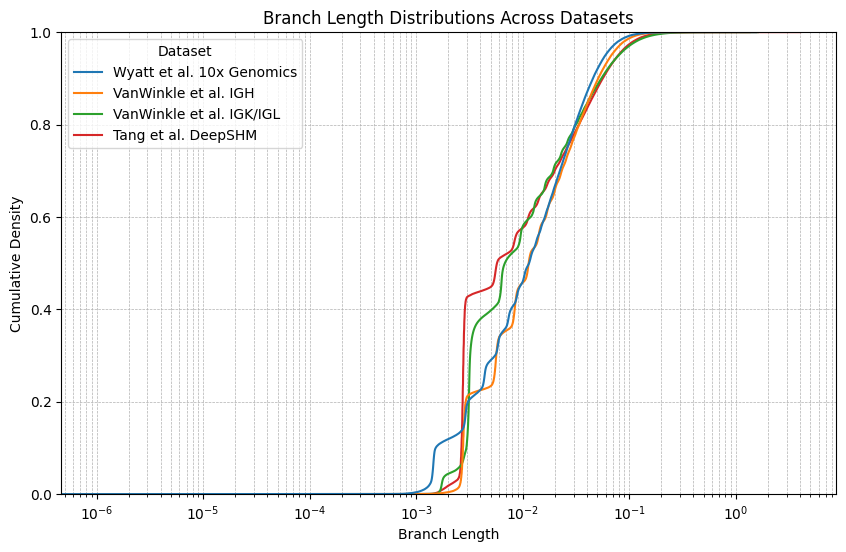

In [29]:
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df_branch_lengths_merged, x="Branch Length", hue="Dataset", legend=True)
plt.xlabel("Branch Length")
plt.xscale("log")
plt.ylabel("Cumulative Density")
plt.title("Branch Length Distributions Across Datasets")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

In [80]:
# wyatt_df = handle_gaps_and_count_muts(wyatt_df)
vanwinkle_igh_df = handle_gaps_and_count_muts(vanwinkle_igh_df)
vanwinkle_igk_df = handle_gaps_and_count_muts(vanwinkle_igk_df)
tang_df = handle_gaps_and_count_muts(tang_df)

100%|██████████| 651935/651935 [01:40<00:00, 6463.02it/s]


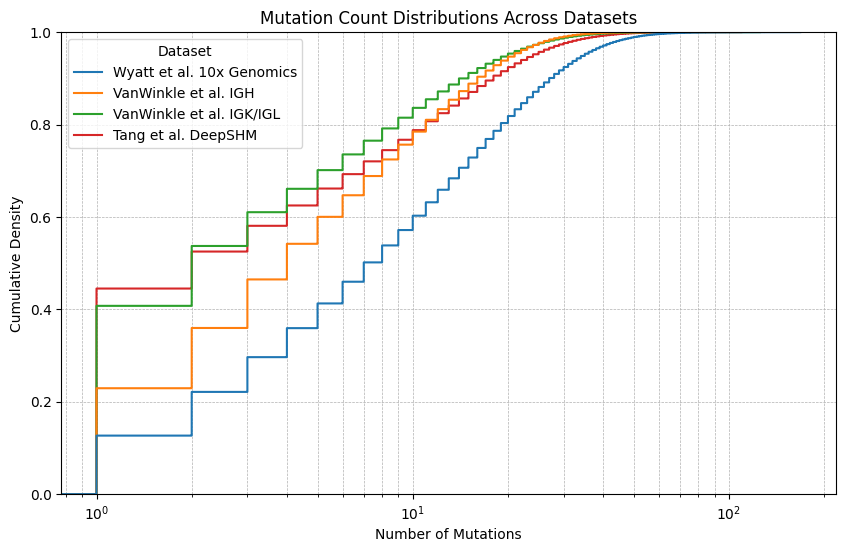

In [ ]:
# plot the mutation count cdf distributions for all datasets, similar to branch lengths
df_mut_counts_merged = pd.DataFrame({
    "Number of Mutations": np.concatenate([
        wyatt_df.n_mut.values,
        vanwinkle_igh_df.n_mut.values,
        vanwinkle_igk_df.n_mut.values,
        tang_df.n_mut.values,
    ]),
    "Dataset": ["Wyatt et al. 10x Genomics"] * len(wyatt_df) +
                ["VanWinkle et al. IGH"] * len(vanwinkle_igh_df) +
                ["VanWinkle et al. IGK/IGL"]
                * len(vanwinkle_igk_df) +
                ["Tang et al. DeepSHM"] * len(tang_df)
})  

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df_mut_counts_merged, x="Number of Mutations", hue="Dataset", legend=True)
plt.xlabel("Number of Mutations")
plt.xscale("log")
plt.ylabel("Cumulative Density")
plt.title("Mutation Count CDF Across Datasets")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

In [82]:
# save these processed data to disk
output_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/dasm/raw")
output_dir.mkdir(parents=True, exist_ok=True)
wyatt_df.to_csv(output_dir / "wyatt-paired.csv")
vanwinkle_igh_df.to_csv(output_dir / "vanwinkle-igh.csv")
vanwinkle_igk_df.to_csv(output_dir / "vanwinkle-igk.csv")
tang_df.to_csv(output_dir / "tang-igh.csv")

In [83]:
# print sizes of the raw datasets
print(f"Wyatt et al. 10x Genomics: {len(wyatt_df)}")
print(f"VanWinkle et al. IGH: {len(vanwinkle_igh_df)}")
print(f"VanWinkle et al. IGK/IGL: {len(vanwinkle_igk_df)}")
print(f"Tang et al. DeepSHM: {len(tang_df)}")

Wyatt et al. 10x Genomics: 209599
VanWinkle et al. IGH: 124985
VanWinkle et al. IGK/IGL: 1000000
Tang et al. DeepSHM: 651935


In [84]:
# remove all rows that have identical parent and child amino acid sequences (i.e. no mutations)
wyatt_df = wyatt_df[
    (wyatt_df['parent_heavy_aa'] != wyatt_df['child_heavy_aa']) |
    (wyatt_df['parent_light_aa'] != wyatt_df['child_light_aa'])
]
vanwinkle_igh_df = vanwinkle_igh_df[
    (vanwinkle_igh_df['parent_heavy_aa'] != vanwinkle_igh_df['child_heavy_aa'])
]
vanwinkle_igk_df = vanwinkle_igk_df[
    (vanwinkle_igk_df['parent_light_aa'] != vanwinkle_igk_df['child_light_aa'])
]
tang_df = tang_df[
    (tang_df['parent_heavy_aa'] != tang_df['child_heavy_aa'])
]

In [85]:
# print sizes after removing non-transitions
print(f"Wyatt et al. 10x Genomics (post-filter): {len(wyatt_df)}")
print(f"VanWinkle et al. IGH (post-filter): {len(vanwinkle_igh_df)}")
print(f"VanWinkle et al. IGK/IGL (post-filter): {len(vanwinkle_igk_df)}")
print(f"Tang et al. DeepSHM (post-filter): {len(tang_df)}")

Wyatt et al. 10x Genomics (post-filter): 196456
VanWinkle et al. IGH (post-filter): 112490
VanWinkle et al. IGK/IGL (post-filter): 855449
Tang et al. DeepSHM (post-filter): 557479


In [86]:
# remove rows with duplicate edge ids
wyatt_df = wyatt_df.drop_duplicates(subset=['edge_id'])
vanwinkle_igh_df = vanwinkle_igh_df.drop_duplicates(subset=['edge_id'])
vanwinkle_igk_df = vanwinkle_igk_df.drop_duplicates(subset=['edge_id'])
tang_df = tang_df.drop_duplicates(subset=['edge_id'])

# print sizes after removing duplicate edge ids
print(f"Wyatt et al. 10x Genomics (post-dedup): {len(wyatt_df)}")
print(f"VanWinkle et al. IGH (post-dedup): {len(vanwinkle_igh_df)}")
print(f"VanWinkle et al. IGK/IGL (post-dedup): {len(vanwinkle_igk_df)}")
print(f"Tang et al. DeepSHM (post-dedup): {len(tang_df)}")

Wyatt et al. 10x Genomics (post-dedup): 196456
VanWinkle et al. IGH (post-dedup): 112490
VanWinkle et al. IGK/IGL (post-dedup): 855449
Tang et al. DeepSHM (post-dedup): 557479


In [87]:
# save processed data to disk
output_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/dasm/processed")
output_dir.mkdir(parents=True, exist_ok=True)
wyatt_df.to_csv(output_dir / "wyatt-paired.csv")
vanwinkle_igh_df.to_csv(output_dir / "vanwinkle-igh.csv")
vanwinkle_igk_df.to_csv(output_dir / "vanwinkle-igk.csv")
tang_df.to_csv(output_dir / "tang-igh.csv")

In [39]:
print(wyatt_df['parent_heavy'].iloc[0])
print(wyatt_df['child_heavy'].iloc[0])
print()
print(vanwinkle_igh_df['parent_heavy'].iloc[0])
print(vanwinkle_igh_df['child_heavy'].iloc[0])
print()
print(vanwinkle_igk_df['parent_light'].iloc[0])
print(vanwinkle_igk_df['child_light'].iloc[0])
print()
print(tang_df['parent_heavy'].iloc[0])
print(tang_df['child_heavy'].iloc[0])
print()

CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAGGCCTGGGGCCTCAGTGAAGGTTTCCTGCAAGGCTTCTGGATACACCTTCACTAGTCATCCTATAAATTGGGTGCGACAGGTCCCTGGACAGGGGCTTGAGTGGATGGGATGGATCAACACCAACACTGGGAACCCAACGTATGCCCAGGGCTTCACAGGACGGTTTGTCTTGTCCTTGGACACCTCTGTCAGCACGGCATATCTGCAGATCAGCAGCCTAAAGGCTGAGGACACTGCCGTATATTACTGTGCGAGAGATAGGTGGGATAACGATCTTTTAATTGGCCTTGAGTATTGGGGCCAGGGAACCCTGGTCACCGTCTCCTCA
CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAGGCCTGGGGCCTCAGTGAAGGTTTCCTGCAAGGCTTCTGGATACACCTTCACTAGTCATCCTATAAATTGGGTGCGACAGGTCCCTGGACAGGGGCTTGAGTGGATGGGATGGATCAACACCAACACTGGGAACCCAACGTATGCCCAGGGCTTCACAGGACGCTTTGTCTTGTCATCGGACACCTCTGTCAGCACGGCATATCTGCAGATCAGCAGCCTAAAGGCTGAGGACACTGCCGTATATTACTGTGCGAGAGATAGGTGGGATAACGATCTTTTAATTGGCCTTGAGTATTGGGGCCAGGGAACCCTGGTCACCGTCTCCTCA

GAGGTGCAACTGGTGGAGTCTGGAGGAGGCTTGATCCAGCCGGGGGGGTCCCTGAGACTCTCCTGTGCAGCCTCGGGTTTCGCCGTCGGCACTACCTACATGGCCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGCAGTGGGTCTCAGTCATTTATACCTATGGCAACACAGACTACGCAGACTCCGTGAAGGGCCGATTCACCATCTCCAGAGACAATTCCAAGAACACGCTGTCTCTTCAAATGAGCAGCGTTAGAGCCGAGG

## Post processing to get transitions

In [3]:
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/dasm/processed")
wyatt_df = pd.read_csv(data_dir / "wyatt-paired.csv", index_col=0)
vanwinkle_igh_df = pd.read_csv(data_dir / "vanwinkle-igh.csv", index_col=0)
vanwinkle_igk_df = pd.read_csv(data_dir / "vanwinkle-igk.csv", index_col=0)
tang_df = pd.read_csv(data_dir / "tang-igh.csv", index_col=0)

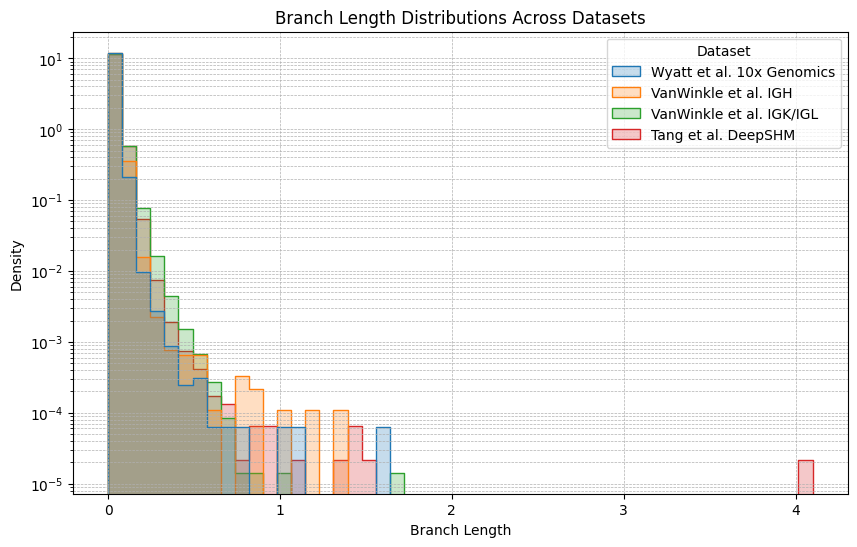

In [6]:
df_branch_lengths_merged = pd.DataFrame({
    "Branch Length": np.concatenate([
        wyatt_df.branch_length.values,
        vanwinkle_igh_df.branch_length.values,
        vanwinkle_igk_df.branch_length.values,
        tang_df.branch_length.values,
    ]),
    "Dataset": ["Wyatt et al. 10x Genomics"] * len(wyatt_df) +
                ["VanWinkle et al. IGH"] * len(vanwinkle_igh_df) +
                ["VanWinkle et al. IGK/IGL"] * len(vanwinkle_igk_df) +
                ["Tang et al. DeepSHM"] * len(tang_df)
})

# plot histogram of branch lengths on log scale
plt.figure(figsize=(10, 6))
sns.histplot(data=df_branch_lengths_merged, x="Branch Length", hue="Dataset", element="step", stat="density", common_norm=False, bins=50)
plt.xlabel("Branch Length")
plt.yscale("log")
plt.ylabel("Density")
plt.title("Branch Length Distributions Across Datasets")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()